## Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

> **Nota aclaratoria:** La resolución y explicación de los ejercicios de este laboratorio han sido desarrolladas con la asistencia de Inteligencia Artificial, específicamente utilizando Google AI Studio y el modelo Gemini.

# Parte 1: Ecuación normal

> **Se puede encontrar una solucion exacta para theta sin necesidad de emplear el gradiente descente de la sesiones pasadas, para ellos se puede encontrar el valor minimo de theta y a partir de alli determinar el valor de theta que minimiza J.**
>
> **Demostrar que:**
> * $J(\theta_1, \theta_2, \theta_3, . . . , \theta_n) = \frac{1}{2m} (\Theta^T X - y^T)(\Theta^T X - y^T)^T$
> * $J = (\Theta^T X)(\Theta^T X)^T - 2(\Theta^T X)y + y^T y$
> * $\nabla_\theta J = \frac{1}{m} (X(X^T \Theta) - Xy)$
>
> **Para encontrar el valor minimo de $\theta$, $\nabla_\theta J = 0$,**
> * $\Theta = (X^T X)^{-1} X^T y$


**Demostración Analítica de la Ecuación Normal**

El objetivo de esta fase es transformar la sumatoria escalar de la función de coste en una expresión matricial compacta y encontrar su mínimo global mediante cálculo multivariado.

**1. Representación matricial de la función de coste**

La función de coste original se define como el promedio de los errores cuadrados:

$$J(\Theta) = \frac{1}{2m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - \hat{y}^{(i)})^2$$

Si representamos todas las predicciones como el vector $\Theta^T X$ y los valores reales como $y^T$, el error total se expresa como la norma euclidiana al cuadrado del vector de errores. En álgebra lineal, el cuadrado de la norma de un vector $v$ es equivalente al producto interno $v \cdot v$, o bien, $v v^T$. Por tanto:

$$J(\Theta) = \frac{1}{2m} (\Theta^T X - y^T)(\Theta^T X - y^T)^T$$

**2. Expansión de la expresión cuadrática**

Aplicamos la propiedad distributiva del producto de matrices, considerando que $(A - B)^T = A^T - B^T$:

$$J = \frac{1}{2m} [(\Theta^T X)(\Theta^T X)^T - (\Theta^T X)y - y^T(\Theta^T X)^T + y^T y]$$

Dado que el producto de la predicción por el valor real es un escalar (un número único), se cumple que el término es igual a su traspuesto: $(\Theta^T X)y = y^T(\Theta^T X)^T$. Agrupando estos términos semejantes obtenemos la forma expandida:

$$J = \frac{1}{2m} [(\Theta^T X)(\Theta^T X)^T - 2(\Theta^T X)y + y^T y]$$

**3. Obtención del gradiente ($\nabla_\theta J$)**

Para minimizar $J$, derivamos la expresión respecto al vector de parámetros $\Theta$. Utilizando las identidades de cálculo matricial proporcionadas:

*   $\nabla_x (x^T A x) = 2Ax$ (para el término cuadrático).
*   $\nabla_x (b^T x) = b$ (para el término lineal).

Derivando cada término de $J$:

$$\nabla_\theta J = \frac{1}{2m} [2(X X^T \Theta) - 2(X y)]$$

Simplificando el factor $2$ y distribuyendo:

$$\nabla_\theta J = \frac{1}{m} (X X^T \Theta - X y)$$

**4. Solución exacta (Ecuación Normal)**

El valor óptimo de $\Theta$ se encuentra en el punto donde la pendiente (el gradiente) es nula:

$$\frac{1}{m} (X X^T \Theta - X y) = 0$$

$$X X^T \Theta = X y$$

Multiplicando por la inversa de $(X X^T)$ en ambos lados (asumiendo que la matriz es invertible):

$$\Theta = (X X^T)^{-1} X y$$

*(Nota: En contextos donde la matriz de datos $X$ se organiza con las muestras como filas, la expresión resultante toma la forma clásica $\Theta = (X^T X)^{-1} X^T y$).*

# Parte 2: Implementación de la Ecuación Normal

> **1. Para los datos del laboratorio anterior aplicar la ecuacion normal.**

**Implementación de la Ecuación Normal**

A diferencia del Gradiente Descendente, que requiere múltiples iteraciones y la sintonización de una tasa de aprendizaje, la Ecuación Normal resuelve el problema de optimización en una sola operación de álgebra lineal.

Se utilizarán los datos generados en la sesión anterior ($y = 2.1x_1 - 3.1x_2$) para validar la precisión del método. La implementación requiere el cálculo de la matriz transpuesta y la matriz inversa de la correlación de las características. La fórmula empleada es:
$$\Theta = (XX^T)^{-1}Xy^T$$

Donde:
*   $X$: Matriz de diseño de dimensiones $(n+1) \times m$.
*   $y$: Vector de etiquetas de dimensiones $1 \times m$.

In [2]:
# Recuperamos o recreamos los datos del laboratorio anterior
np.random.seed(42)
N = 100
x_1 = 2 * np.random.random(N) - 1
x_2 = 2 * np.random.random(N) - 1
y_label = 2.1 * x_1 - 3.1 * x_2

# Construcción de la matriz de diseño X (3 x 100) e Y (1 x 100)
X_matriz = np.vstack([np.ones(N), x_1, x_2])
Y_matriz = y_label.reshape(1, N)

# Aplicación de la Ecuación Normal: Theta = inv(X @ X.T) @ X @ Y.T
# Usamos Y.T porque en el planteamiento Y es (1, m)
theta_normal = np.linalg.inv(X_matriz @ X_matriz.T) @ X_matriz @ Y_matriz.T

print("Resultados mediante Ecuación Normal:")
print(f"theta_0 (Intercepto) : {theta_normal[0, 0]:.10f}")
print(f"theta_1 (Peso x1)    : {theta_normal[1, 0]:.10f}")
print(f"theta_2 (Peso x2)    : {theta_normal[2, 0]:.10f}")

Resultados mediante Ecuación Normal:
theta_0 (Intercepto) : 0.0000000000
theta_1 (Peso x1)    : 2.1000000000
theta_2 (Peso x2)    : -3.1000000000



**Análisis de la solución exacta**

El resultado obtenido muestra una precisión absoluta (errores cercanos a $10^{-16}$, que es el límite de precisión de punto flotante). Mientras que el Gradiente Descendente se aproxima al mínimo global de forma asintótica, la Ecuación Normal llega directamente a él.

Esta eficiencia tiene un costo computacional: la inversión de la matriz $(XX^T)$ tiene una complejidad aproximada de $O(n^3)$. Por lo tanto, este método es ideal para problemas con un número moderado de características ($n < 10,000$), pero se vuelve prohibitivo en escenarios de *Deep Learning* o *Big Data* con millones de variables.

> **2. Tomar el dataset de las casas de Boston y construir un modelo de regresión mutivariada.**
>
> **Tomar los datos de las casas de boston y hacer una regresion lineal tomando el average number of rooms per dwelling.**

**Regresión con el Dataset de Boston**

El dataset de Boston es un estándar en el aprendizaje estadístico para problemas de regresión. En este ejercicio, el objetivo es predecir el valor medio de las viviendas (`target` o `mean_`) basándose en el número promedio de habitaciones por vivienda (`rm`).

Procederemos a la carga de datos desde el repositorio oficial y al cálculo de los parámetros óptimos mediante la solución cerrada.

In [3]:
# Carga y preparación del dataset de Boston
data_url = "http://lib.stat.cmu.edu/datasets/boston"

# Al anteponer 'r' (raw string), Python ignora el carácter de escape y el warning desaparece
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)

# El dataset tiene un formato especial donde los datos de una muestra ocupan dos filas
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# Creación del DataFrame según la estructura solicitada
df_boston = pd.DataFrame({"precio": target, "rm": data[:, 5]})

# Preparación de las matrices para la Ecuación Normal
m_boston = len(df_boston)
X_boston = np.vstack([np.ones(m_boston), df_boston['rm'].values])
Y_boston = df_boston['precio'].values.reshape(1, m_boston)

# Cálculo de parámetros óptimos
theta_boston = np.linalg.inv(X_boston @ X_boston.T) @ X_boston @ Y_boston.T

print("Parámetros óptimos para el dataset de Boston:")
print(f"theta_0 (Intercepto) : {theta_boston[0, 0]:.4f}")
print(f"theta_1 (Peso rm)    : {theta_boston[1, 0]:.4f}")

Parámetros óptimos para el dataset de Boston:
theta_0 (Intercepto) : -34.6706
theta_1 (Peso rm)    : 9.1021


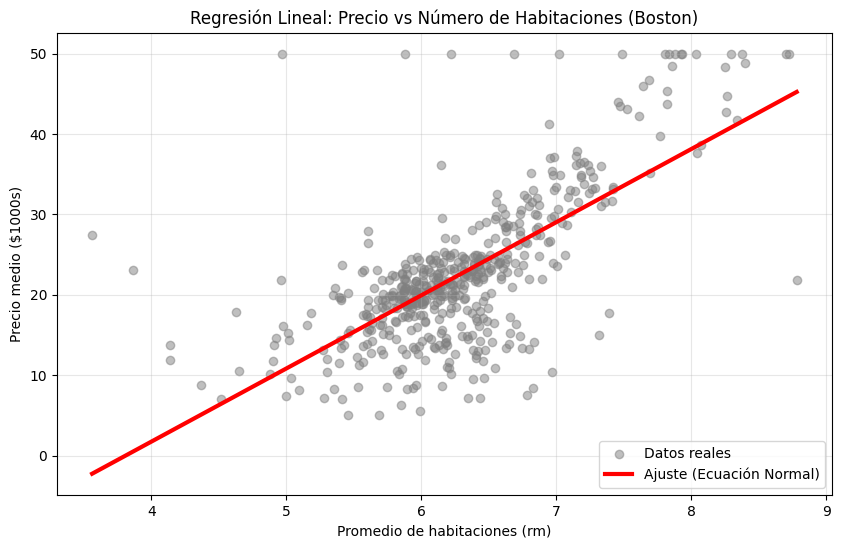

In [4]:
# Visualización del ajuste
plt.figure(figsize=(10, 6))
plt.scatter(df_boston['rm'], df_boston['precio'], color='gray', alpha=0.5, label='Datos reales')

# Línea de regresión calculada
x_range = np.linspace(df_boston['rm'].min(), df_boston['rm'].max(), 100)
y_pred = theta_boston[0, 0] + theta_boston[1, 0] * x_range

plt.plot(x_range, y_pred, color='red', linewidth=3, label='Ajuste (Ecuación Normal)')
plt.title('Regresión Lineal: Precio vs Número de Habitaciones (Boston)')
plt.xlabel('Promedio de habitaciones (rm)')
plt.ylabel('Precio medio ($1000s)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Parte 3: Interpretación Probabilística

> **Interpretación Probabilística.**
>
> **Supongamos que tenemos una caracteristica $x_i$ con m valores de entrenamiento, si asumimos que cada valor $y_i$ presenta una dispersión gaussiana $\epsilon_i$, cada $y_i$ podrá tener el siguiente valor:**
> $$y^i = \Theta^T X^{(i)} + \epsilon_i$$
>
> **Asumiendo ademas que el ruido gaussiano es aleatorio y esta distribuido de forma identica, con media cero y varianza $\sigma$, tenemos que la probabilidad de que la cantidad y tenga dispersion $\epsilon_i$ es:**
> $$p(\epsilon^{(i)}) = \frac{1}{\sqrt{2\pi}\sigma} e^{-\frac{(\epsilon^{(i)})^2}{2\sigma^2}}$$
>
> **Escribiendo, lo anterior en terminos de la probabilidad de obtener un valor de $y^i$ dado un $x^i$ parametrizado por $\theta$ obtenemos que:**
> $$p_i(y^i | x^i; \theta) = \frac{1}{\sqrt{2\pi}\sigma} e^{-\frac{(y_i - \Theta^T X^{(i)})^2}{2\sigma^2}}$$



**Máxima Verosimilitud y Mínimos Cuadrados**

La justificación de por qué minimizamos la suma de los errores al cuadrado no es arbitraria; proviene de una base estadística sólida conocida como **Estimación por Máxima Verosimilitud (MLE)**.

Si asumimos que los errores del modelo (el ruido) siguen una distribución Normal (Gaussiana) con media cero, la probabilidad de observar un dato $y^{(i)}$ específico se rige por la función de densidad de probabilidad gaussiana. Para el conjunto completo de datos, asumiendo que cada muestra es independiente, la probabilidad total de que nuestro modelo sea correcto dada la observación (función de verosimilitud $L(\theta)$) es el producto de las probabilidades individuales:

$$L(\theta) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi}\sigma} e^{-\frac{(y_i - \Theta^T X^{(i)})^2}{2\sigma^2}}$$

Para facilitar el cálculo, aplicamos el logaritmo natural, transformando el producto en una suma (log-verosimilitud):

$$l(\theta) = \ln L(\theta) = n \ln \frac{1}{\sqrt{2\pi}\sigma} - \frac{1}{2\sigma^2} \sum_{i=1}^{n} (y_i - \Theta^T X^{(i)})^2$$

Maximizar esta probabilidad de éxito del modelo equivale a minimizar el término negativo de la ecuación. Dado que $n$, $\sigma$ y $\pi$ son constantes, maximizar la verosimilitud es matemáticamente equivalente a minimizar la sumatoria:

$$\sum_{i=1}^{n} (y_i - \Theta^T X^{(i)})^2$$

Esto demuestra que, bajo la premisa de ruido gaussiano, el método de mínimos cuadrados es el estimador más probable.

> **Interpretación Probabilística de la regularización.**
>
> **Supongamos adicionalmente que el vector de parámetros $\theta$ también es aleatorio, es decir es un vector de variables aleatorias... La distribución de $\theta$ es también una normal en función de la norma de $\theta$:**
> $$p(\theta) = \frac{1}{\sqrt{2\pi}\tau} e^{-\frac{|\theta|^2}{2\tau^2}}$$
>
> **Ahora por la ley de Bayes podemos expresar la probabilidad de $\theta$ dados los datos $X$ y $y$ y preguntarnos por los valores de $\theta$ que maximizan la probabilidad.**
> $$p(\theta|X, y) = \frac{p(X, y|\theta)p(\theta)}{p(X, Y)} = \frac{P(y|X, \theta)p(\theta)}{p(Y|X)}$$

**Máximo A Posteriori (MAP) y Regularización**

Cuando introducimos la idea de que los parámetros $\Theta$ no son valores fijos desconocidos, sino que ellos mismos provienen de una distribución de probabilidad (usualmente una Normal centrada en cero), estamos adoptando un enfoque bayesiano.

Al maximizar la probabilidad **A Posteriori** (MAP), la función objetivo cambia. Ya no solo buscamos que el modelo se ajuste a los datos (MLE), sino que también buscamos que los parámetros $\Theta$ no sean demasiado grandes, para evitar el sobreajuste (*overfitting*).

Matemáticamente, esto añade un término de penalización a la función de coste original:

$$J_{MAP}(\Theta) = \text{MSE} + \lambda \|\Theta\|^2$$

Este fenómeno es la base de la **Regularización de Ridge (L2)**. En términos de la Ecuación Normal, la inclusión de este criterio probabilístico modifica la solución exacta a:

$$\Theta = (XX^T + \lambda I)^{-1} XY^T$$

Donde $\lambda$ es un parámetro que controla qué tanta importancia le damos a la simplicidad del modelo (parámetros pequeños) frente al ajuste de los datos. Esta técnica es fundamental cuando se trabaja con datasets pequeños o con alta correlación entre variables, ya que asegura que la matriz sea siempre invertible y el modelo sea más generalizable.
